----------------------------------------------------------------------------------------------------

# ***FastAPI - Outras instalações necessárias***

O tutorial liberado no site estava depreciado no momento em que fiz o curso, porém tentarei seguir o atualizado:

Tutorial: https://fastapi.tiangolo.com/async/

----------------------------------------------------------------------------------------------------

# ***1. Comandos:*** 

## ***1.1 Poetry:***

Vá no Terminal e digite:

poetry add "databases[aiosqlite]"

### ***1.1.1. Resposta esperada:***

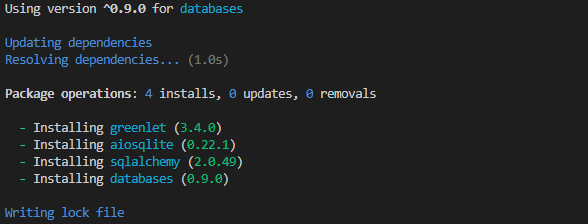

----------------------------------------------------------------------------------------------------

# ***2. Criando a conexão*** 

No arquivo 'main.py', implemente no código os seguintes trechos:

In [ ]:
from fastapi import FastAPI
import sqlalchemy # importacao necessaria
from controllers import post

# instanciando a classe SQLalchemmy
metadata = sqlalchemy.MetaData()


app = FastAPI()
app.include_router(post.router)

## ***2.1. Criando novo arquivo:***

Agora, no seu projeto, crie a pasta 'models', caso não exista e o arquivo 'post.py', dentro dela.

## ***2.2. post.py***

No arquivo, adicione o seguinte código:

In [ ]:
import sqlalchemy
from app.main import metadata

posts = sqlalchemy.Table(
    "posts",
    metadata,
    sqlalchemy.Column("id", sqlalchemy.Integer, primary_key= True),
    sqlalchemy.Column("title", sqlalchemy.String(150), null = False, unique = False),
    sqlalchemy.Column("content", sqlalchemy.String, nullable = False),
    sqlalchemy.Column("published_at", sqlalchemy.DateTime, nullable = True),
    sqlalchemy.Column("published", sqlalchemy.Boolean, default = False)

)

## ***2.2. Adicionando a 'engine' e 'lifespan'***

Tutorial: https://fastapi.tiangolo.com/advanced/events/

No arquivo 'main', adicionaremos a 'engine' que é necessária:

In [ ]:
from contextlib import asynccontextmanager

import databases # importacao necessaria
from fastapi import FastAPI
import sqlalchemy # importacao necessaria
from controllers import post

DATABASE_URL = 'sqlite:///./blog.db'

# cria database
database = databases.Database(DATABASE_URL)
# instanciando a classe SQLalchemmy
metadata = sqlalchemy.MetaData()
engine = sqlalchemy.create_engine(DATABASE_URL, connect_args = {"check_same_thread": False})
# utiliza a engine:
metadata.create_all(engine)

@asynccontextmanager
async def lifespan(app: FastAPI):
    await database.connect()
    yield
    await database.disconnect()

app = FastAPI(lifespan= None)
app.include_router(post.router)
